# Li-ion Battery Health and Lifetime Analysis



## 1. Data Understanding

In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt

metadata = pd.read_csv('./metadata.csv')
metadata.head()

,type,start_time,ambient_temperature,battery_id,test_id,uid,filename,Capacity,Re,Rct
0,discharge,[2010. 7. 21. 15. 0. ...,4,B0047,0,1,00001.csv,1.6743047446975208,NaN,NaN
1,impedance,[2010. 7. 21. 16. 53. ...,24,B0047,1,2,00002.csv,NaN,0.05605783343888099,0.20097016584458333
2,charge,[2010. 7. 21. 17. 25. ...,4,B0047,2,3,00003.csv,NaN,NaN,NaN
3,impedance,[2010 7 21 20 31 5],24,B0047,3,4,00004.csv,NaN,0.05319185850921101,0.16473399914864734
4,discharge,[2.0100e+03 7.0000e+00 2.1000e+01 2.1000e+01 2...,4,B0047,4,5,00005.csv,1.5243662105099023,NaN,NaN


### 1.1 Battery Groups

Based on the `Extra_infos/` README files, the batteries are organized into the following groups with their respective ambient temperatures:

| Group | Batteries | Ambient Temperature (°C) |
| :--- | :--- | :--- |
| **Group 1** | B0005, B0006, B0007, B0018 | 24 | 
| **Group 2** | B0025, B0026, B0027, B0028 | 24 | 
| **Group 3** | B0029, B0030, B0031, B0032 | 43 | 
| **Group 4** | B0033, B0034, B0036 | 4 | 
| **Group 5** | B0038, B0039, B0040 | 24, 44 | 
| **Group 6** | B0041, B0042, B0043, B0044 | 22, 24, 4 | 
| **Group 7** | B0045, B0046, B0047, B0048 | 4, 24 | 
| **Group 8** | B0049, B0050, B0051, B0052 | 4, 24 | 
| **Group 9** | B0053, B0054, B0055, B0056 | 4, 24 | 



In [14]:
# Ambient temperature per battery
metadata.groupby('battery_id')['ambient_temperature'].unique()

battery_id
B0005           [24]
B0006           [24]
B0007           [24]
B0018           [24]
B0025           [24]
B0026           [24]
B0027           [24]
B0028           [24]
B0029           [43]
B0030           [43]
B0031           [43]
B0032           [43]
B0033           [24]
B0034           [24]
B0036           [24]
B0038       [24, 44]
B0039       [24, 44]
B0040       [24, 44]
B0041        [4, 24]
B0042    [22, 24, 4]
B0043    [22, 24, 4]
B0044    [22, 24, 4]
B0045        [4, 24]
B0046        [4, 24]
B0047        [4, 24]
B0048        [4, 24]
B0049        [4, 24]
B0050        [4, 24]
B0051        [4, 24]
B0052        [4, 24]
B0053        [4, 24]
B0054        [4, 24]
B0055        [4, 24]
B0056        [4, 24]
Name: ambient_temperature, dtype: object

### 1.2 Dataset Characteristics

#### Similarities Across All Battery Sets:
- **Charging Protocol**: All batteries use the same CC+CV (Constant Current + Constant Voltage) charging protocol — 1.5A CC until 4.2V, then CV until current drops to 20mA.
- **Impedance Measurement**: All impedance cycles use the same EIS (Electrochemical Impedance Spectroscopy) frequency sweep from 0.1Hz to 5kHz.
- **Impedance Data Structure**: All impedance cycles contain exactly **48 rows** (frequency counted 48 times).

#### Main Variables Across Datasets:
- **Temperature**: Ambient temperature varies across battery groups (4°C, 22-24°C, 43-44°C).
- **Discharge Method/Load Profile**: Different discharge currents (1A, 2A, 4A) and cutoff voltages (2.0V, 2.2V, 2.5V, 2.7V) are used across different battery groups.

## 2. Field-wise Data Exploration

### 2.1  Type Field

The dataset contains three types of operations: **charge**, **discharge**, and **impedance**.

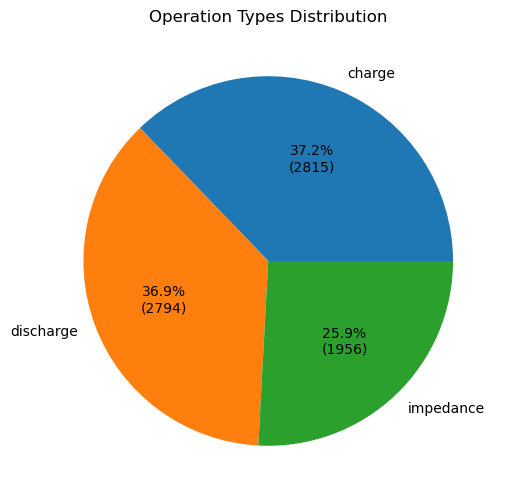

In [3]:
# Get counts
counts = metadata['type'].value_counts()

# Define a function to show counts + percentage
def func(pct, allvals):
    absolute = int(round(pct/100.*sum(allvals)))
    return f"{pct:.1f}%\n({absolute})"

# Plot pie chart
counts.plot.pie(autopct=lambda pct: func(pct, counts), figsize=(6,6))
plt.ylabel('')  # Optional: remove y-label
plt.title("Operation Types Distribution")
plt.show()

We expect a regular cycle pattern (e.g., Charge -> Discharge -> Impedance). However, there are cases where the same operation type repeats consecutively.

**Observations:**
- **Total consecutive occurrences:** 29
- **There is Missing Discharge -not recorder:** 7 cases (indices 1470, 3179, 4020, 4100, 4527, 5143, 5759)
- **Top-off Charges:** 4 cases where battery was already full (e.g., indices 4588, 5204, 5820, 6467)

In [4]:
# Identify consecutive rows with the same operation type
metadata['prev_type'] = metadata['type'].shift(1)
consecutive_mask = metadata['type'] == metadata['prev_type']
consecutive_anomalies = metadata[consecutive_mask]

print(f"Total consecutive anomalies found: {len(consecutive_anomalies)}")

# Show the distribution of repeated types
print("\nDistribution of repeated operation types:")
print(consecutive_anomalies['type'].value_counts())


Total consecutive anomalies found: 29

Distribution of repeated operation types:
type
charge       16
impedance    10
discharge     3
Name: count, dtype: int64


### 2.2 Start Time Field

The `start_time` field currently contains string representations of MATLAB date vectors (e.g., `[2010. 8. 7. 11. 26. ...]`). We will standardize this into a consistent `YYYY-MM-DD HH:MM:SS.sss` format.

In [5]:
import re
from datetime import datetime

def parse_matlab_date_vector(date_str):
    try:
        # Remove brackets and extra spaces
        clean_str = date_str.strip('[]').strip()
        # Split by whitespace (handles multiple spaces)
        parts = re.split(r'\s+', clean_str)
        # Convert to floats
        parts = [float(p) for p in parts]
        
        # Extract components
        year = int(parts[0])
        month = int(parts[1])
        day = int(parts[2])
        hour = int(parts[3])
        minute = int(parts[4])
        second = parts[5]
        
        # Handle seconds and microseconds
        sec_int = int(second)
        microsec = int((second - sec_int) * 1_000_000)
        
        dt = datetime(year, month, day, hour, minute, sec_int, microsec)
        return dt.strftime('%Y-%m-%d %H:%M:%S.%f')[:-3] # Format to milliseconds
    except Exception as e:
        return f"Error: {e}"

# Apply the parsing function
metadata['start_time'] = metadata['start_time'].apply(parse_matlab_date_vector)

# Verify the new format
print("Sample of standardized start_time:")
print(metadata['start_time'].sample(5))

Sample of standardized start_time:
1054    2009-04-13 19:04:39.468
1883    2009-06-28 13:46:26.405
2250    2009-08-22 14:34:05.875
4783    2008-05-06 12:50:20.780
7471    2010-09-20 11:25:31.155
Name: start_time, dtype: object


#### Chronological Consistency Check

We verify that for each battery, the `start_time` increases as the `test_id` increases. This ensures the data is chronologically consistent.

In [6]:
# Ensure start_time is datetime
metadata['start_time_dt'] = pd.to_datetime(metadata['start_time'])

# Sort by battery_id and test_id
metadata = metadata.sort_values(by=['battery_id', 'test_id'])

# Calculate time difference between consecutive rows within each battery
metadata['time_diff'] = metadata.groupby('battery_id')['start_time_dt'].diff()

# Check for negative time differences (violations)
# We ignore the first record of each group (NaT)
violations = metadata[metadata['time_diff'] < pd.Timedelta(0)]

if violations.empty:
    print("Chronological order is satisfied: As test_id increases, start_time increases for all batteries.")
else:
    print(f"Found {len(violations)} chronological violations!")
    print(violations[['battery_id', 'test_id', 'start_time', 'time_diff']])

Chronological order is satisfied: As test_id increases, start_time increases for all batteries.


#### Experiment Duration per Battery

We calculate the total time span of the experiment for each battery (difference between the last and first recorded timestamp).

,min_time,max_time,count,span_days
battery_id,,,,
B0005,2008-04-02 13:08:17.920,2008-05-28 11:09:42.045,616,55.917640
B0006,2008-04-02 13:08:17.920,2008-05-28 11:09:42.045,616,55.917640
B0007,2008-04-02 13:08:17.920,2008-05-28 11:09:42.045,616,55.917640
B0018,2008-07-07 12:26:45.750,2008-08-20 08:37:19.515,319,43.840669
B0025,2009-02-13 19:03:52.109,2009-03-19 12:55:26.718,80,33.744151
B0026,2009-02-13 19:03:52.109,2009-03-19 12:55:26.718,80,33.744151
B0027,2009-02-13 19:03:52.109,2009-03-19 12:55:26.718,80,33.744151
B0028,2009-02-13 19:03:52.109,2009-03-19 12:55:26.718,80,33.744151
B0029,2009-04-07 15:59:18.718,2009-04-18 01:29:13.015,97,10.395767


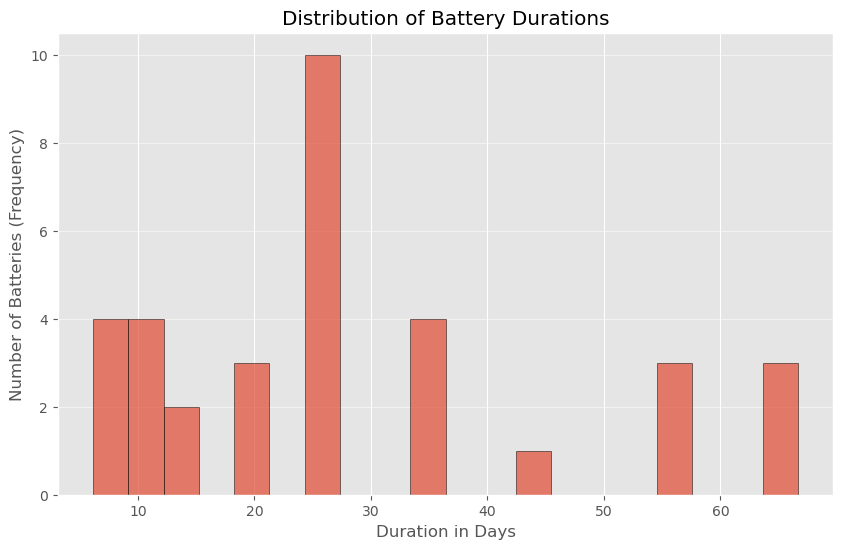

In [7]:
# Group by battery and summarize start/end/count, ensuring datetime type
by_batt = metadata.groupby('battery_id')['start_time_dt']
summary = by_batt.agg(min_time='min', max_time='max', count='count')
summary['span_days'] = (summary['max_time'] - summary['min_time']).dt.total_seconds() / 86400
display(summary)  # Show the summary table

# Set a style for better visualization (optional)
plt.style.use('ggplot')

# Create the histogram
plt.figure(figsize=(10, 6)) # Set figure size for better viewing

# Plot histogram of durations in days
summary['span_days'].hist(bins=20, edgecolor='black', alpha=0.7)
# bins=20: Divides the range of data into 20 bars/buckets

# Add labels and a title for clarity
plt.title('Distribution of Battery Durations')
plt.xlabel('Duration in Days')
plt.ylabel('Number of Batteries (Frequency)')
plt.grid(axis='y', alpha=0.5) # Only show horizontal grid lines

# Display the plot
plt.show()

### 2.3 ambient_temperature Field

#### We Cluster the 5 categories in 3 main categories
We have 4, 22, 24, 43 and 44, we group them into main 3:
  * Cold: 4 degrees
  * Moderate: 22 and 24 degrees
  * Hot: 43 and 44 degrees

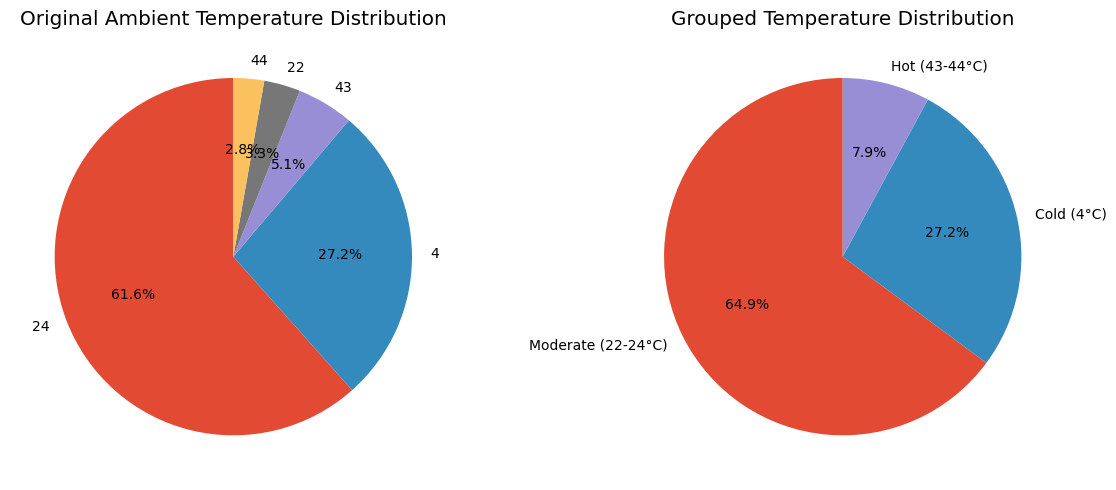

In [8]:
# 1. Original Distribution of Ambient Temperatures
temp_counts = metadata['ambient_temperature'].value_counts()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
temp_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Original Ambient Temperature Distribution')
plt.ylabel('')

# 2. Grouped Distribution
def group_temperature(temp):
    if temp in [22, 24]:
        return 'Moderate (22-24°C)'
    elif temp in [43, 44]:
        return 'Hot (43-44°C)'
    else:
        return f'Cold ({temp}°C)'

metadata['temp_group'] = metadata['ambient_temperature'].apply(group_temperature)
grouped_counts = metadata['temp_group'].value_counts()

plt.subplot(1, 2, 2)
grouped_counts.plot.pie(autopct='%1.1f%%', startangle=90)
plt.title('Grouped Temperature Distribution')
plt.ylabel('')

plt.tight_layout()
plt.show()

#### mixed temperature
another potential problem is that there is more than temperature for the same battery like the example below
* in battery *B0041* all charge and discharge cycles are in 4 C while impedance happen in 24 C
* in fact it is 97% of the time the impedance calculated on 24 degree (it was 43 only in case where charge and discharge of same battery are 43)

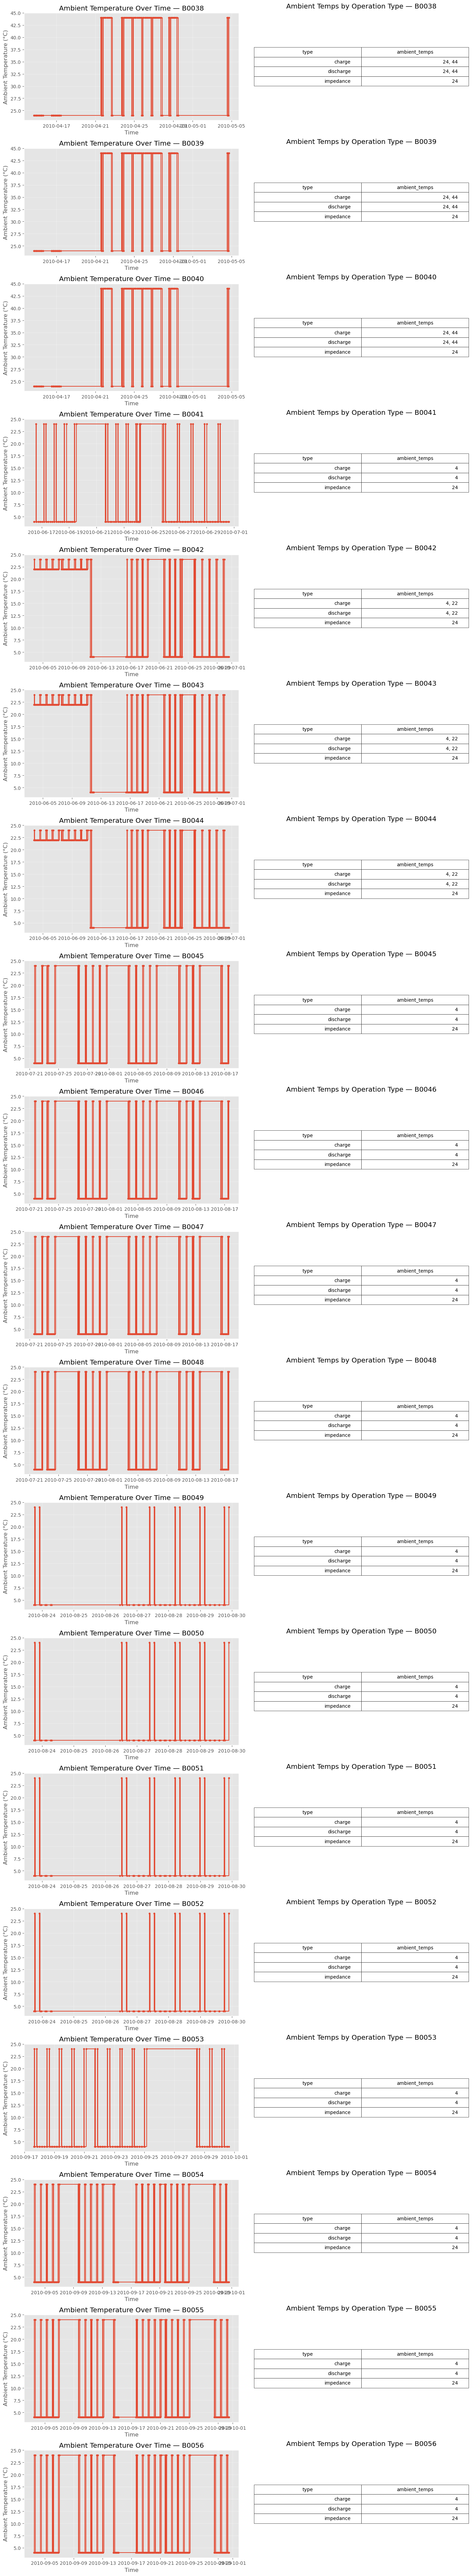

In [9]:
# Batteries B0038 to B0056: temperature over time and per-operation temps side-by-side
import re
batt_nums = range(38, 57)
batt_ids = [f'B00{num}' if num < 100 else f'B0{num}' for num in batt_nums]

n_batts = len(batt_ids)
fig, axes = plt.subplots(n_batts, 2, figsize=(14, 4*n_batts))

for i, batt_id in enumerate(batt_ids):
    batt_data = metadata[metadata['battery_id'] == batt_id].sort_values('start_time_dt')
    temps_by_type = (
        batt_data.groupby('type')['ambient_temperature']
        .unique()
        .apply(lambda arr: ', '.join(str(int(x)) for x in sorted(arr)))
        .reset_index()
        .rename(columns={'ambient_temperature': 'ambient_temps'})
)
    # Left: temperature step plot
    axes[i, 0].plot(batt_data['start_time_dt'], batt_data['ambient_temperature'],
                    marker='.', linestyle='-', drawstyle='steps-post')
    axes[i, 0].set_title(f'Ambient Temperature Over Time — {batt_id}')
    axes[i, 0].set_xlabel('Time')
    axes[i, 0].set_ylabel('Ambient Temperature (°C)')
    axes[i, 0].grid(True, alpha=0.4)
    # Right: table of temps by operation type
    axes[i, 1].axis('tight')
    axes[i, 1].axis('off')
    table = axes[i, 1].table(cellText=temps_by_type.values,
                            colLabels=temps_by_type.columns,
                            loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.4)
    axes[i, 1].set_title(f'Ambient Temps by Operation Type — {batt_id}', pad=10)

plt.tight_layout()
plt.show()

#### Does ambient temperature influence battery lifespan or cycle duration?


C:\Users\Noufel\AppData\Local\Temp\ipykernel_16080\4098070120.py:38: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cycle_durations['temp_group'] = cycle_durations['ambient_temperature'].apply(group_temperature)


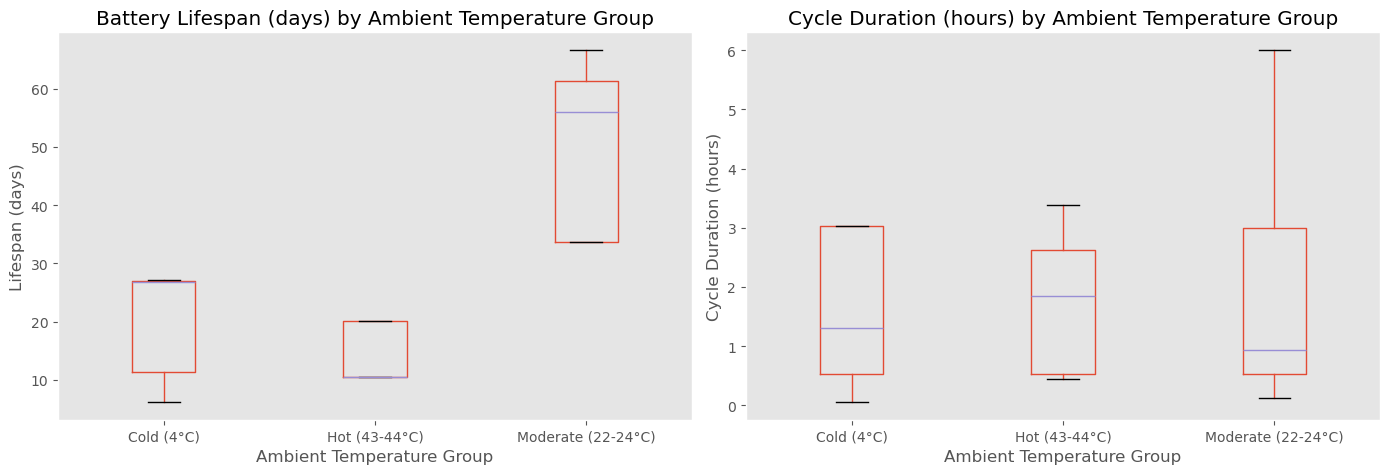


=== Battery Lifespan Statistics by Temperature Group ===


,count,mean,std,min,25%,50%,75%,max
temp_group,,,,,,,,
Cold (4°C),16.0,20.100167,9.431121,6.167001,11.299426,26.864892,26.992403,27.140346
Hot (43-44°C),7.0,14.532492,5.159403,10.395767,10.395767,10.395767,20.048126,20.048126
Moderate (22-24°C),11.0,49.680042,14.245078,33.744151,33.744151,55.917640,61.277199,66.636758



=== Cycle Duration Statistics by Temperature Group ===


,count,mean,std,min,25%,50%,75%,max
temp_group,,,,,,,,
Cold (4°C),2047.0,3.018736,9.457291,0.052300,0.531476,1.305464,3.021706,106.895746
Hot (43-44°C),594.0,3.561392,12.002401,0.438620,0.528728,1.841398,2.631950,120.967040
Moderate (22-24°C),4890.0,3.063525,17.008356,0.119179,0.535048,0.932496,3.000877,307.166984


In [10]:

# 1. Battery Lifespan Analysis
# Calculate lifespan (experiment span in days) for each battery
batt_lifespan = metadata.groupby('battery_id')['start_time_dt'].agg(['min', 'max'])
batt_lifespan['lifespan_days'] = (batt_lifespan['max'] - batt_lifespan['min']).dt.total_seconds() / 86400

# Get the main ambient temperature for each battery (mode)
batt_temp = metadata.groupby('battery_id')['ambient_temperature'].agg(lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0])

# Merge
batt_lifespan = batt_lifespan.join(batt_temp.rename('main_temp'))

# Group temperature into categories
def group_temperature(temp):
    if temp in [22, 24]:
        return 'Moderate (22-24°C)'
    elif temp in [43, 44]:
        return 'Hot (43-44°C)'
    else:
        return f'Cold ({temp}°C)'

batt_lifespan['temp_group'] = batt_lifespan['main_temp'].apply(group_temperature)

# Visualization and Statistics
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Boxplot: Lifespan by temperature group
batt_lifespan.boxplot(column='lifespan_days', by='temp_group', ax=axes[0], grid=False)
axes[0].set_title('Battery Lifespan (days) by Ambient Temperature Group')
axes[0].set_xlabel('Ambient Temperature Group')
axes[0].set_ylabel('Lifespan (days)')
plt.sca(axes[0])
plt.xticks(rotation=0)

# 2. Cycle Duration Analysis
# Calculate time between consecutive cycles
metadata['cycle_duration_hr'] = metadata.groupby('battery_id')['start_time_dt'].diff().dt.total_seconds() / 3600
cycle_durations = metadata.dropna(subset=['cycle_duration_hr'])
cycle_durations['temp_group'] = cycle_durations['ambient_temperature'].apply(group_temperature)

# Boxplot: Cycle duration by temperature group (without outliers for clarity)
cycle_durations.boxplot(column='cycle_duration_hr', by='temp_group', ax=axes[1], grid=False, showfliers=False)
axes[1].set_title('Cycle Duration (hours) by Ambient Temperature Group')
axes[1].set_xlabel('Ambient Temperature Group')
axes[1].set_ylabel('Cycle Duration (hours)')
plt.sca(axes[1])
plt.xticks(rotation=0)

plt.suptitle('')  # Remove the automatic suptitle
plt.tight_layout()
plt.show()

# Display summary statistics
print("\n=== Battery Lifespan Statistics by Temperature Group ===")
display(batt_lifespan.groupby('temp_group')['lifespan_days'].describe())

print("\n=== Cycle Duration Statistics by Temperature Group ===")
display(cycle_durations.groupby('temp_group')['cycle_duration_hr'].describe())

### 2.4 Battery ID Field

#### Battery Groups Comparison

Compare cycles and duration across different battery groups defined in the Extra_infos folder.

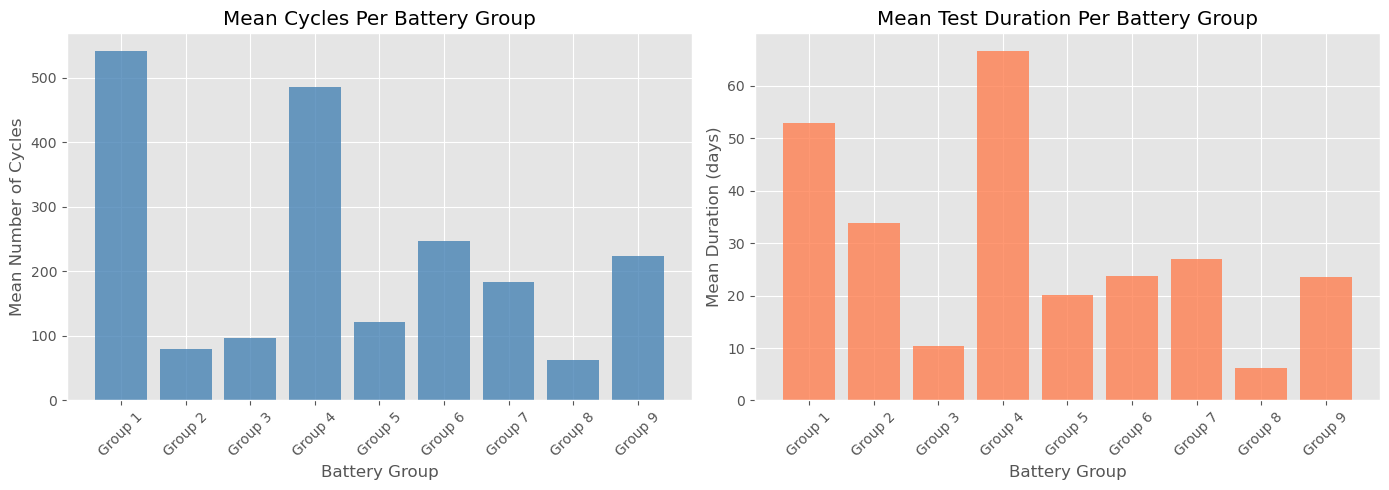

In [11]:
# Define battery groups based on Extra_infos folder
battery_groups = {
    'Group 1': ['B0005', 'B0006', 'B0007', 'B0018'],
    'Group 2': ['B0025', 'B0026', 'B0027', 'B0028'],
    'Group 3': ['B0029', 'B0030', 'B0031', 'B0032'],
    'Group 4': ['B0033', 'B0034', 'B0036'],
    'Group 5': ['B0038', 'B0039', 'B0040'],
    'Group 6': ['B0041', 'B0042', 'B0043', 'B0044'],
    'Group 7': ['B0045', 'B0046', 'B0047', 'B0048'],
    'Group 8': ['B0049', 'B0050', 'B0051', 'B0052'],
    'Group 9': ['B0053', 'B0054', 'B0055', 'B0056']
}

# Calculate cycles per battery
cycles_per_battery = metadata.groupby('battery_id').size()

# Calculate duration per battery (in days)
duration_per_battery = metadata.groupby('battery_id')['start_time_dt'].agg(['min', 'max'])
duration_per_battery['duration_days'] = (duration_per_battery['max'] - duration_per_battery['min']).dt.total_seconds() / 86400

# Prepare group-level statistics
group_stats = []
for group_name, batteries in battery_groups.items():
    # Filter batteries that exist in the dataset
    existing_batteries = [b for b in batteries if b in cycles_per_battery.index]
    
    if existing_batteries:
        cycles = cycles_per_battery[existing_batteries]
        durations = duration_per_battery.loc[existing_batteries, 'duration_days']
        
        group_stats.append({
            'Group': group_name,
            'Batteries': ', '.join(existing_batteries),
            'Cycles_Min': cycles.min(),
            'Cycles_Max': cycles.max(),
            'Cycles_Mean': cycles.mean(),
            'Duration_Min': durations.min(),
            'Duration_Max': durations.max(),
            'Duration_Mean': durations.mean()
        })

group_stats_df = pd.DataFrame(group_stats)

# Visualization - Mean values only
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Mean Cycles per battery
x_pos = np.arange(len(group_stats_df))

axes[0].bar(x_pos, group_stats_df['Cycles_Mean'], alpha=0.8, color='steelblue')
axes[0].set_xlabel('Battery Group')
axes[0].set_ylabel('Mean Number of Cycles')
axes[0].set_title('Mean Cycles Per Battery Group')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(group_stats_df['Group'], rotation=45)

# 2. Mean Duration per battery
axes[1].bar(x_pos, group_stats_df['Duration_Mean'], alpha=0.8, color='coral')
axes[1].set_xlabel('Battery Group')
axes[1].set_ylabel('Mean Duration (days)')
axes[1].set_title('Mean Test Duration Per Battery Group')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(group_stats_df['Group'], rotation=45)

plt.tight_layout()
plt.show()

### 2.5 Test ID Field

The `test_id` field is a numeric, ordered categorical field indicating the cycle index.
* I have verified the consistency of test_id and it is consistent

### 2.6 Capacity Field

* capacity values appear only when type == discharge

#### Missing values

* We can handle 0's using interpolation
* in battery 52 the most of the capacity is missing

In [12]:
# Get discharge records
discharge_records = metadata[metadata['type'] == 'discharge']

# Find indexes where Capacity is 0 (including 0.0)
zero_capacity_idx = discharge_records[discharge_records['Capacity'].apply(
    lambda x: (isinstance(x, (int, float)) and x == 0) or (isinstance(x, str) and x == '0')
)].index.tolist()

# Find indexes where Capacity is an empty list []
# Empty lists are stored as strings '[]' or actual empty lists
empty_list_idx = discharge_records[discharge_records['Capacity'].apply(
    lambda x: (isinstance(x, list) and len(x) == 0) or (isinstance(x, str) and x == '[]')
)].index.tolist()

print(f"Indexes with Capacity = 0 (Total: {len(zero_capacity_idx)}):")
print(zero_capacity_idx)

print(f"\nIndexes with Capacity = [] (Total: {len(empty_list_idx)}):")
print(empty_list_idx)

Indexes with Capacity = 0 (Total: 19):
[1543, 750, 3252, 234, 348, 602, 684, 716, 50, 132, 164, 418, 500, 532, 4296, 4358, 4482, 6807, 7060]

Indexes with Capacity = [] (Total: 25):
[4370, 4372, 4374, 4376, 4390, 4394, 4396, 4398, 4400, 4402, 4406, 4408, 4410, 4412, 4414, 4418, 4420, 4422, 4424, 4426, 4430, 4432, 4434, 4436, 4438]


#### Usage of the battery

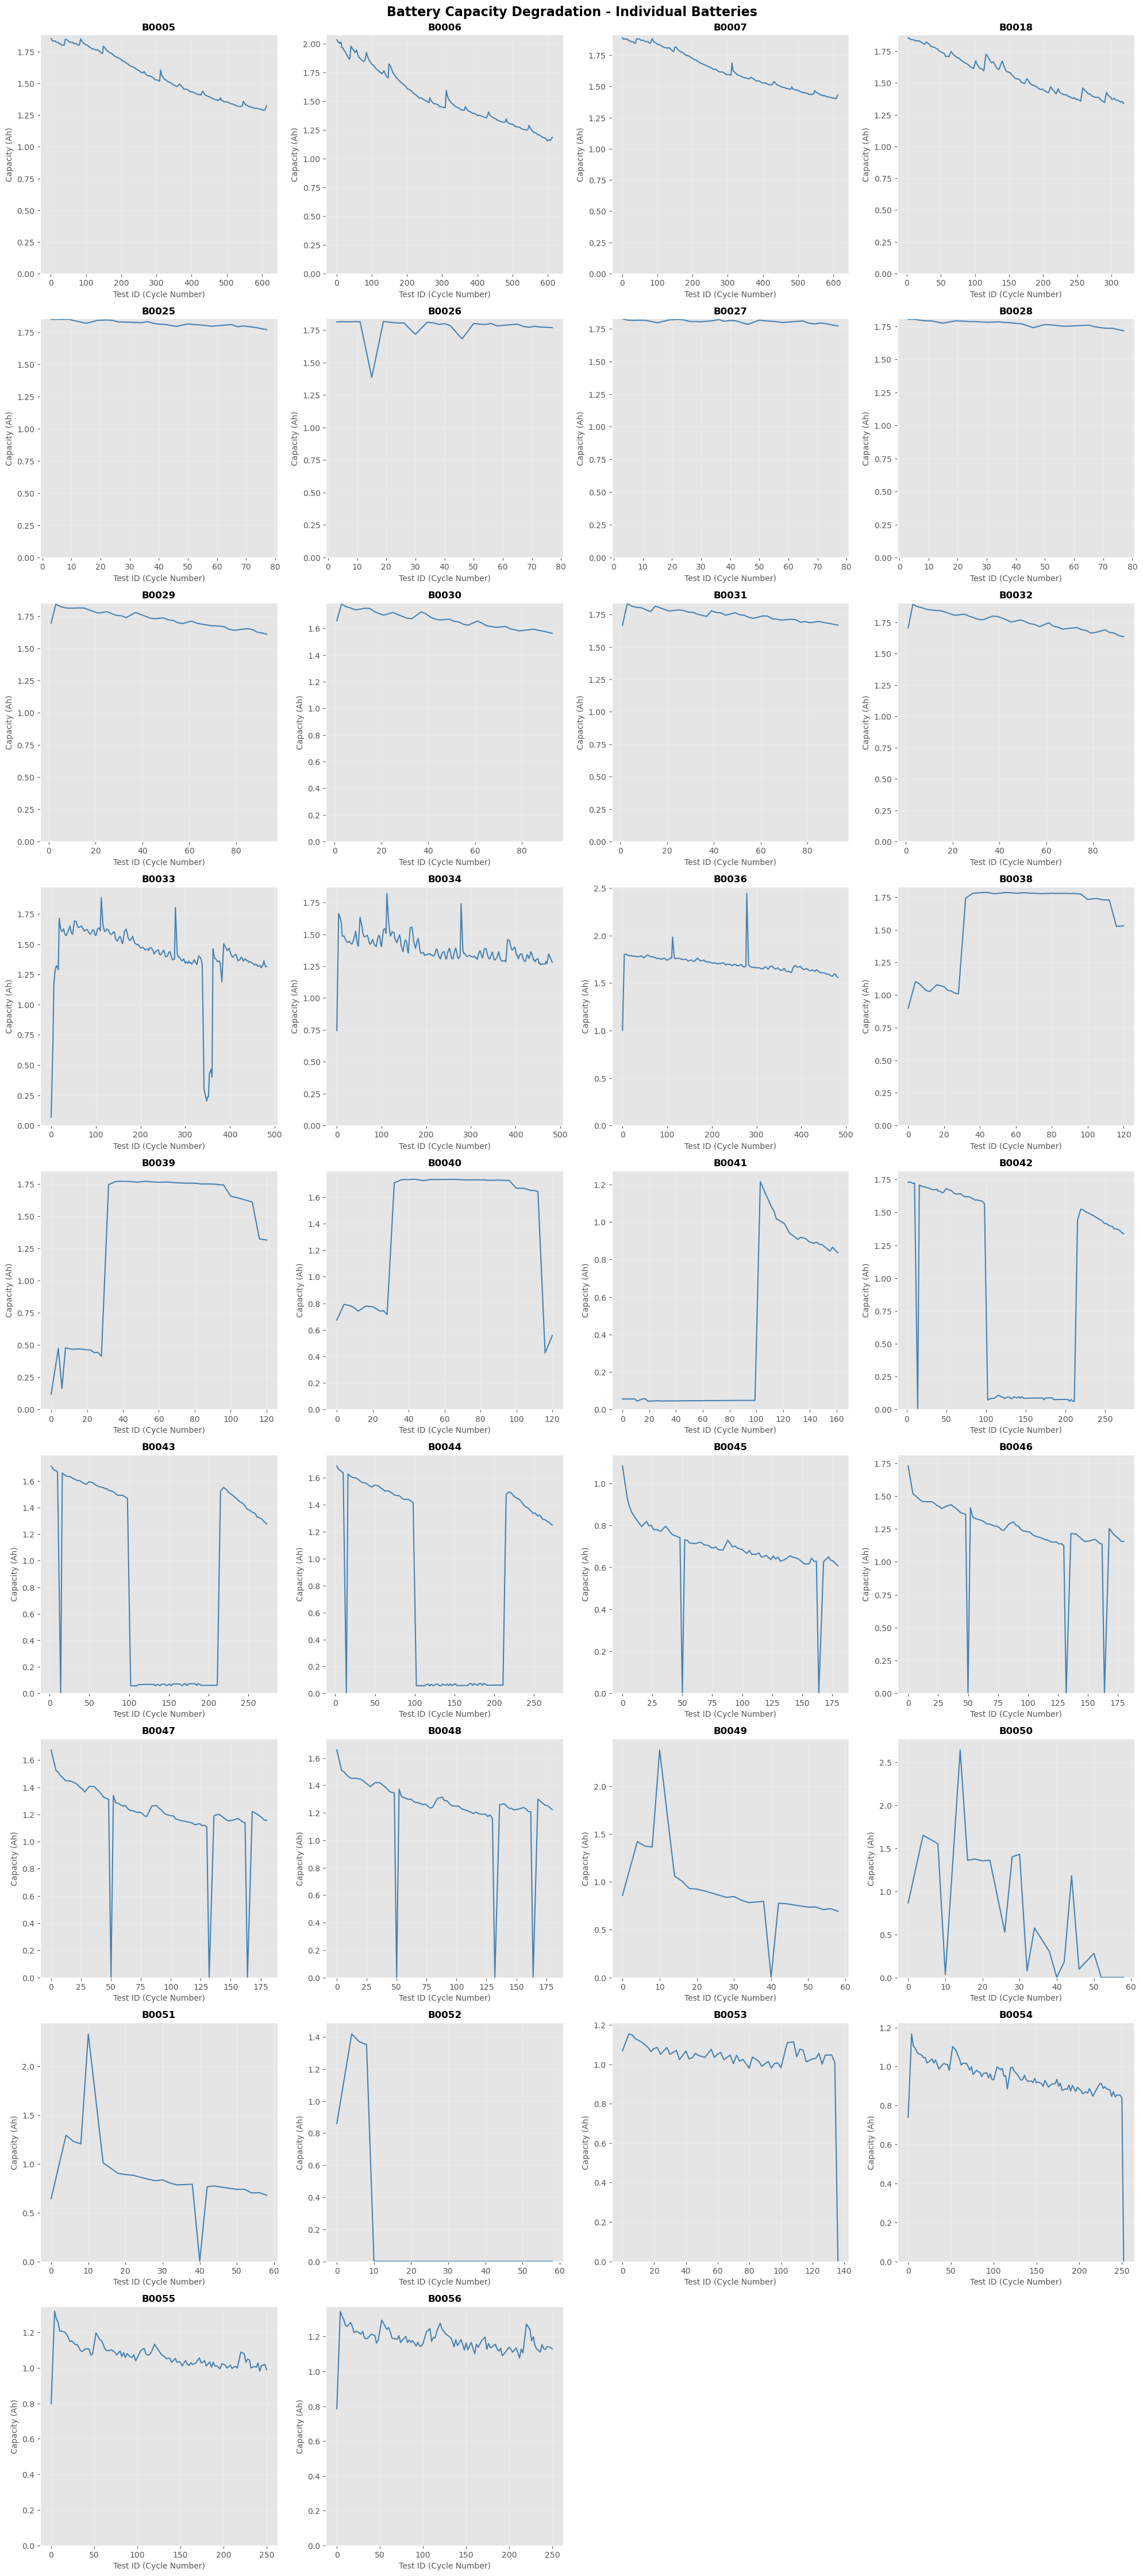

In [13]:
# Filter for discharge cycles
discharge_data = metadata[metadata['type'] == 'discharge'].copy()

# Function to clean and convert capacity
def clean_capacity(val):
    # Handle list type (empty or not)
    if isinstance(val, list):
        return 0.0 if len(val) == 0 else float(val[0])
    
    # Handle string type
    if isinstance(val, str):
        val = val.strip()
        if val == '[]':
            return 0.0
        try:
            return float(val)
        except ValueError:
            return 0.0
            
    # Handle numeric types
    if isinstance(val, (int, float)):
        return float(val)
        
    return 0.0

# Apply cleaning
discharge_data['Capacity'] = discharge_data['Capacity'].apply(clean_capacity)

# Get unique batteries and sort them
batteries = sorted(discharge_data['battery_id'].unique())

# Calculate grid dimensions
n_batteries = len(batteries)
n_cols = 4
n_rows = int(np.ceil(n_batteries / n_cols))

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
axes = axes.flatten()

# Plot each battery in its own subplot
for idx, batt in enumerate(batteries):
    batt_df = discharge_data[discharge_data['battery_id'] == batt].sort_values('test_id')
    
    axes[idx].plot(batt_df['test_id'], batt_df['Capacity'], linewidth=1.5, color='steelblue')
    axes[idx].set_title(f'{batt}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Test ID (Cycle Number)', fontsize=10)
    axes[idx].set_ylabel('Capacity (Ah)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_ylim(bottom=0)

# Hide unused subplots
for idx in range(n_batteries, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Battery Capacity Degradation - Individual Batteries', fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

In [17]:
metadata[metadata['type'] == 'impedance']['Re'].value_counts().sort_index().head(30)

Re
(0.04993924107250144-0.029292986079855882j)    1
(0.06042629807036345-0.03892605001625892j)     1
(0.06997578649953896-0.03540956964931328j)     1
(0.08161887029141376-0.024860963384487754j)    1
(0.08234891316262448-0.022577075672314314j)    1
(0.08241814902922012-0.022224149442637422j)    1
(0.08640994631573766-0.0371087352306254j)      1
(0.08704709068864393-0.014743181821969856j)    1
(0.09131086461416552-0.008052597399499057j)    1
-1132.4980536723524                            1
-127177.84648781897                            1
-3202.8764806439913                            1
-4050.7544527422683                            1
-4986.050426740892                             1
-5470.6838293611745                            1
-5756.374362090784                             1
-7997.932807178092                             1
-968924452345684.0                             1
-97766.36180381701                             1
-98579.08687469143                             1
0.027050163015499